Objective: 

In the recruitment domain, HR departments face the significant challenge of verifying candidates' claims regarding their current or previous salaries, as these details heavily influence the salary expectations for the new role. Candidates may misrepresent their salary to secure a higher offer, leading to an inflated compensation structure, potential team imbalances, and an inefficient recruitment process. A data-driven approach to predict and verify salary claims can help recruiters make more informed decisions and minimize the risk of overpayment or recruitment misalignment.
To build a predictive model using Decision Tree and Random Forest algorithms that estimates a candidate’s monthly income based on key variables such as job title, years of experience, and other relevant features. This will help HR teams determine if a candidate’s reported salary aligns with market standards and whether there are indicators of misrepresentation.

Impact: By leveraging predictive models, the HR team can:

Enhance Decision-Making: Accurately assess candidates' salary claims, reducing reliance on subjective judgment.
Optimize Salary Offers: Set appropriate and competitive salary offers aligned with market standards.
Mitigate Hiring Risks: Minimize financial risks related to overcompensation and misrepresentation.



In [210]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor 
from sklearn.linear_model import LinearRegression,SGDRegressor,Lasso 
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.tree import plot_tree 
from sklearn.decomposition import PCA 

In [115]:
df= pd.read_csv("E:/Data Science/13-Decision Tree/HR_DT.csv")
df

,Position of the employee,no of Years of Experience of employee,monthly income of employee
0,Business Analyst,1.1,39343
1,Junior Consultant,1.3,46205
2,Senior Consultant,1.5,37731
3,Manager,2.0,43525
4,Country Manager,2.2,39891
...,...,...,...
191,Region Manager,3.9,55794
192,Partner,4.0,56957
193,Senior Partner,4.0,57081
194,C-level,4.1,61111


In [117]:
df.shape

(196, 3)

In [119]:
# regulartion using 

In [121]:
set(df['Position of the employee'])

{'Business Analyst',
 'C-level',
 'CEO',
 'Country Manager',
 'Junior Consultant',
 'Manager',
 'Partner',
 'Region Manager',
 'Senior Consultant',
 'Senior Partner'}

In [123]:
df['Position of the employee'].value_counts()

Position of the employee
Partner              28
Senior Partner       25
C-level              24
Region Manager       23
CEO                  23
Country Manager      18
Manager              17
Senior Consultant    16
Junior Consultant    14
Business Analyst      8
Name: count, dtype: int64

In [125]:
df.describe()

,no of Years of Experience of employee,monthly income of employee
count,196.000000,196.000000
mean,5.112245,74194.923469
std,2.783993,26731.578387
min,1.000000,37731.000000
25%,3.000000,56430.000000
50%,4.100000,63831.500000
75%,7.100000,98273.000000
max,10.500000,122391.000000


In [127]:
df.shape

(196, 3)

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 3 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Position of the employee               196 non-null    object 
 1   no of Years of Experience of employee  196 non-null    float64
 2    monthly income of employee            196 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 4.7+ KB


In [131]:
df.isnull().sum()

Position of the employee                 0
no of Years of Experience of employee    0
 monthly income of employee              0
dtype: int64

In [133]:
df.duplicated().sum()

38

In [135]:
# duplcate data is present in given data 
df=df.drop_duplicates()

In [137]:
df.duplicated().sum()

0

In [139]:
df.shape

(158, 3)

In [141]:
df['Position of the employee'].value_counts()

Position of the employee
Partner              20
Region Manager       19
Senior Partner       19
C-level              19
CEO                  16
Manager              15
Country Manager      15
Senior Consultant    14
Junior Consultant    13
Business Analyst      8
Name: count, dtype: int64

<Axes: xlabel='Position of the employee'>

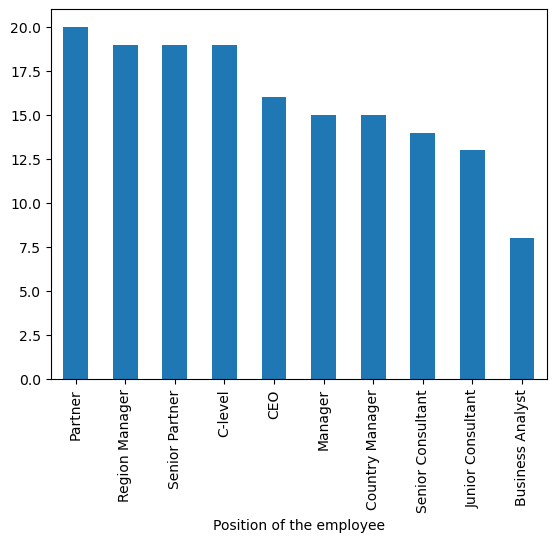

In [143]:
df['Position of the employee'].value_counts().plot(kind='bar')

C:\Users\samir\AppData\Local\Temp\ipykernel_3880\2672585763.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[' monthly income of employee'])


<Axes: xlabel=' monthly income of employee', ylabel='Density'>

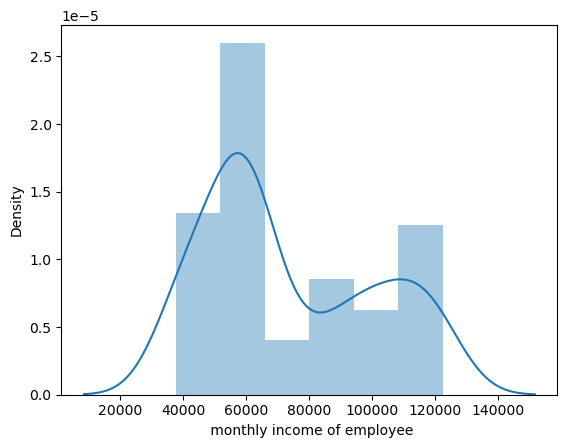

In [144]:
 sns.distplot(df[' monthly income of employee'])

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, 0 to 195
Data columns (total 3 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Position of the employee               158 non-null    object 
 1   no of Years of Experience of employee  158 non-null    float64
 2    monthly income of employee            158 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 4.9+ KB


In [147]:
# one hot incoder 


In [148]:
 one =OneHotEncoder()

In [153]:
m=pd.get_dummies(df['Position of the employee'],dtype=int)

In [155]:
df.shape

(158, 3)

In [157]:
m.shape

(158, 10)

In [159]:
combined_columns = pd.concat([df,m], axis=1)

In [161]:
combined_columns.sample(3)

,Position of the employee,no of Years of Experience of employee,monthly income of employee,Business Analyst,C-level,CEO,Country Manager,Junior Consultant,Manager,Partner,Region Manager,Senior Consultant,Senior Partner
76,Partner,5.1,66029,0,0,0,0,0,0,1,0,0,0
5,Region Manager,2.9,56642,0,0,0,0,0,0,0,1,0,0
184,Region Manager,2.0,39891,0,0,0,0,0,0,0,1,0,0


In [163]:
combined_columns.shape

(158, 13)

In [165]:
combined_columns.isnull().sum()

Position of the employee                 0
no of Years of Experience of employee    0
 monthly income of employee              0
Business Analyst                         0
C-level                                  0
CEO                                      0
Country Manager                          0
Junior Consultant                        0
Manager                                  0
Partner                                  0
Region Manager                           0
Senior Consultant                        0
Senior Partner                           0
dtype: int64

In [167]:
# standigintion 

In [169]:
min=MinMaxScaler()

In [171]:
X=combined_columns.iloc[:,[1,3,4,5,6,7,8,9,10,11,12]]
y=combined_columns[' monthly income of employee']
X.shape

(158, 11)

In [178]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [182]:
reg1=RandomForestRegressor() 

In [186]:
d_reg=DecisionTreeRegressor()
li_reg=LinearRegression()
las_reg =Lasso()

In [188]:
reg1.fit(X_train,y_train)


RandomForestRegressor()

In [192]:
y_pre1=reg1.predict(X_test)
r2_score(y_test,y_pre1)

0.9882170091565164

In [194]:
mean_absolute_error(y_test,y_pre1)

2246.6265781249995

In [196]:
d_reg.fit(X_train,y_train)

DecisionTreeRegressor()

In [200]:
y_pre2=d_reg.predict(X_test)
r2_score(y_test,y_pre2)

0.9840487521335659

In [202]:
li_reg.fit(X_train,y_train)

LinearRegression()

In [204]:
y_pre3=li_reg.predict(X_test)
r2_score(y_test,y_pre3)

0.9549679212892357

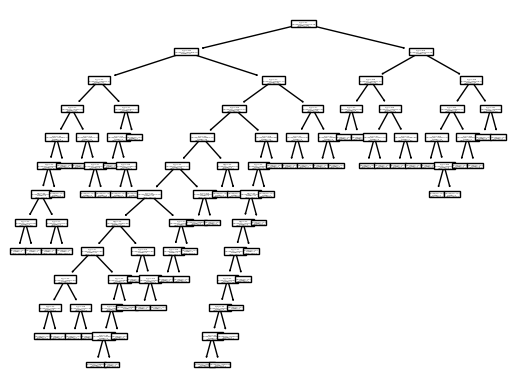

In [208]:
plot_tree(d_reg)
plt.show()

In [212]:
pca=PCA(n_components=2)

In [214]:
X_train_trf=pd.DataFrame(pca.fit_transform(X_train))
X_test_trf =pd.DataFrame(pca.fit_transform(X_test))  
d_reg.fit(X_train_trf,y_train)

DecisionTreeRegressor()

In [216]:
y_pre3=d_reg.predict(X_test_trf)
r2_score(y_test,y_pre3)

0.9492204394139753